# Courtside Alpha — Data Analysis

Comprehensive analysis of all trading data and live game observations collected by the system.

In [23]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import json
from datetime import datetime

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

# ── Load trades ──
conn_t = sqlite3.connect('trades.sqlite')
trades = pd.read_sql('SELECT * FROM simulated_trades ORDER BY timestamp', conn_t)
wallet = pd.read_sql('SELECT * FROM wallet_state', conn_t)
conn_t.close()

trades['timestamp'] = pd.to_datetime(trades['timestamp'])
trades['bought_home'] = trades['bought_home'].map({1: True, 0: False})

# ── Load live observations ──
conn_o = sqlite3.connect('live_observations.sqlite')
snaps = pd.read_sql('SELECT * FROM snapshots ORDER BY recorded_at', conn_o)
conn_o.close()

snaps['recorded_at'] = pd.to_datetime(snaps['recorded_at'])

print(f"Trades loaded: {len(trades)}")
print(f"Live snapshots loaded: {len(snaps)}")
print(f"Games traded: {trades['game_id'].nunique()}")
print(f"Games observed: {snaps.groupby(['home_tricode','away_tricode']).ngroups}")
print(f"Wallet balance: ${wallet['usdc_balance'].iloc[0]:,.2f}")

Trades loaded: 349
Live snapshots loaded: 6807
Games traded: 32
Games observed: 34
Wallet balance: $6,932.38


## 1. Trading Performance Overview

In [24]:
# ── Separate BUY vs SELL rows ──
buys = trades[trades['action'].str.startswith('BUY_')].copy()
sells = trades[~trades['action'].str.startswith('BUY_')].copy()

# Resolved trades = those with non-null, non-zero PnL
resolved = trades[(trades['pnl'].notna()) & (trades['pnl'] != 0)].copy()
wins = resolved[resolved['pnl'] > 0]
losses = resolved[resolved['pnl'] < 0]

total_staked = trades['stake_amount'].sum()
total_pnl = resolved['pnl'].sum()

print("=" * 55)
print("         COURTSIDE ALPHA — PERFORMANCE SUMMARY")
print("=" * 55)
print(f"  Total trades:       {len(trades)}")
print(f"  BUY orders:         {len(buys)}")
print(f"  SELL orders:        {len(sells)}")
print(f"  Open positions:     {len(trades[trades['status'] == 'OPEN'])}")
print(f"  Resolved (w/ PnL):  {len(resolved)}")
print(f"  ─────────────────────────────────────")
print(f"  Wins:               {len(wins)}")
print(f"  Losses:             {len(losses)}")
print(f"  Win rate:           {len(wins)/len(resolved)*100:.1f}%" if len(resolved) > 0 else "  Win rate: N/A")
print(f"  ─────────────────────────────────────")
print(f"  Total PnL:          ${total_pnl:+,.2f}")
print(f"  Won PnL:            ${wins['pnl'].sum():+,.2f}")
print(f"  Lost PnL:           ${losses['pnl'].sum():+,.2f}")
print(f"  Avg win:            ${wins['pnl'].mean():+,.2f}" if len(wins) > 0 else "")
print(f"  Avg loss:           ${losses['pnl'].mean():+,.2f}" if len(losses) > 0 else "")
print(f"  Best trade:         ${resolved['pnl'].max():+,.2f}" if len(resolved) > 0 else "")
print(f"  Worst trade:        ${resolved['pnl'].min():+,.2f}" if len(resolved) > 0 else "")
print(f"  Total staked:       ${total_staked:,.0f}")
print(f"  ROI:                {total_pnl/total_staked*100:+.2f}%" if total_staked > 0 else "")
print("=" * 55)

         COURTSIDE ALPHA — PERFORMANCE SUMMARY
  Total trades:       349
  BUY orders:         204
  SELL orders:        145
  Open positions:     20
  Resolved (w/ PnL):  138
  ─────────────────────────────────────
  Wins:               62
  Losses:             76
  Win rate:           44.9%
  ─────────────────────────────────────
  Total PnL:          $-117.62
  Won PnL:            $+1,237.49
  Lost PnL:           $-1,355.11
  Avg win:            $+19.96
  Avg loss:           $-17.83
  Best trade:         $+221.67
  Worst trade:        $-46.88
  Total staked:       $17,450
  ROI:                -0.67%


## 2. Cumulative PnL Over Time

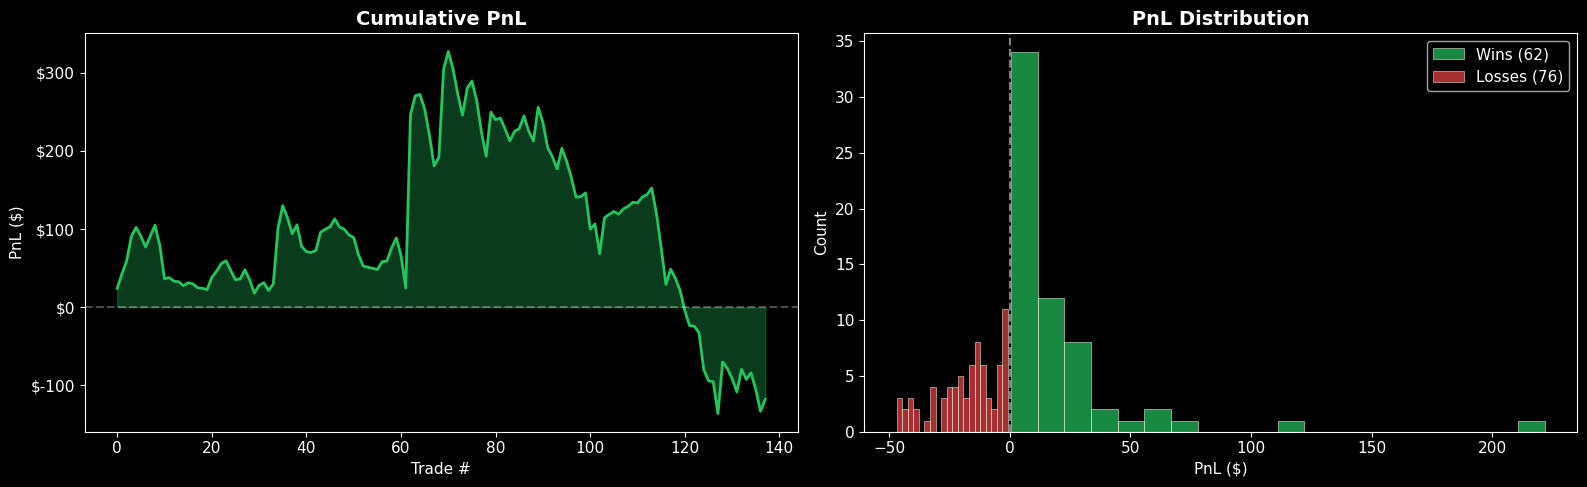

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cumulative PnL
if len(resolved) > 0:
    resolved_sorted = resolved.sort_values('timestamp')
    resolved_sorted['cum_pnl'] = resolved_sorted['pnl'].cumsum()
    
    colors = ['#22c55e' if p > 0 else '#ef4444' for p in resolved_sorted['pnl']]
    axes[0].fill_between(range(len(resolved_sorted)), resolved_sorted['cum_pnl'], alpha=0.3, color='#22c55e')
    axes[0].plot(range(len(resolved_sorted)), resolved_sorted['cum_pnl'], color='#22c55e', linewidth=2)
    axes[0].axhline(y=0, color='white', linestyle='--', alpha=0.3)
    axes[0].set_title('Cumulative PnL', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Trade #')
    axes[0].set_ylabel('PnL ($)')
    axes[0].yaxis.set_major_formatter(mtick.FormatStrFormatter('$%.0f'))

# PnL distribution
if len(resolved) > 0:
    axes[1].hist(wins['pnl'], bins=20, alpha=0.7, color='#22c55e', label=f'Wins ({len(wins)})', edgecolor='white', linewidth=0.5)
    axes[1].hist(losses['pnl'], bins=20, alpha=0.7, color='#ef4444', label=f'Losses ({len(losses)})', edgecolor='white', linewidth=0.5)
    axes[1].axvline(x=0, color='white', linestyle='--', alpha=0.5)
    axes[1].set_title('PnL Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('PnL ($)')
    axes[1].set_ylabel('Count')
    axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Edge Analysis — Model vs Market at Trade Time

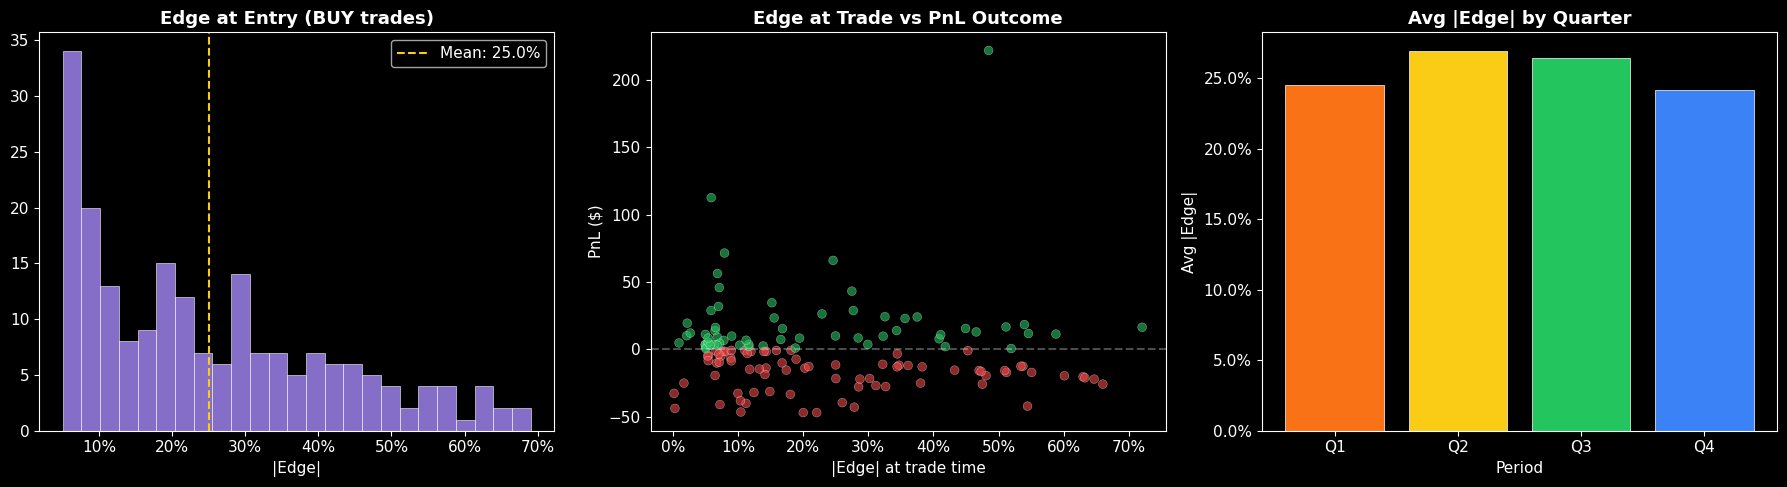

In [26]:
# Edge = model_implied_prob - market_implied_prob (raw, from home perspective)
trades['edge'] = trades['model_implied_prob'] - trades['market_implied_prob']

# Refresh subsets so they have the new column
buys = trades[trades['action'].str.startswith('BUY_')].copy()
sells = trades[~trades['action'].str.startswith('BUY_')].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Edge at entry for BUY trades
buy_edges = buys['edge'].abs()
axes[0].hist(buy_edges, bins=25, color='#a78bfa', edgecolor='white', linewidth=0.5, alpha=0.8)
axes[0].axvline(x=buy_edges.mean(), color='#facc15', linestyle='--', label=f'Mean: {buy_edges.mean():.1%}')
axes[0].set_title('Edge at Entry (BUY trades)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('|Edge|')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].legend()

# Edge vs PnL for resolved sells
if len(resolved) > 0:
    sell_resolved = resolved.copy()
    sell_resolved['abs_edge'] = (sell_resolved['model_implied_prob'] - sell_resolved['market_implied_prob']).abs()
    colors = ['#22c55e' if p > 0 else '#ef4444' for p in sell_resolved['pnl']]
    axes[1].scatter(sell_resolved['abs_edge'], sell_resolved['pnl'], c=colors, alpha=0.6, s=40, edgecolors='white', linewidth=0.3)
    axes[1].axhline(y=0, color='white', linestyle='--', alpha=0.3)
    axes[1].set_title('Edge at Trade vs PnL Outcome', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('|Edge| at trade time')
    axes[1].set_ylabel('PnL ($)')
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Edge by quarter
if 'period' in buys.columns:
    q_edges = buys.groupby('period')['edge'].apply(lambda x: x.abs().mean())
    bars = axes[2].bar(q_edges.index, q_edges.values, color=['#f97316','#facc15','#22c55e','#3b82f6','#a78bfa'][:len(q_edges)],
                       edgecolor='white', linewidth=0.5)
    axes[2].set_title('Avg |Edge| by Quarter', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Period')
    axes[2].set_ylabel('Avg |Edge|')
    axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[2].set_xticks(q_edges.index)
    axes[2].set_xticklabels([f'Q{int(q)}' for q in q_edges.index])

plt.tight_layout()
plt.show()

## 4. Model Accuracy — Live Predictions vs Actual Outcomes

Snapshots with known outcomes: 6807


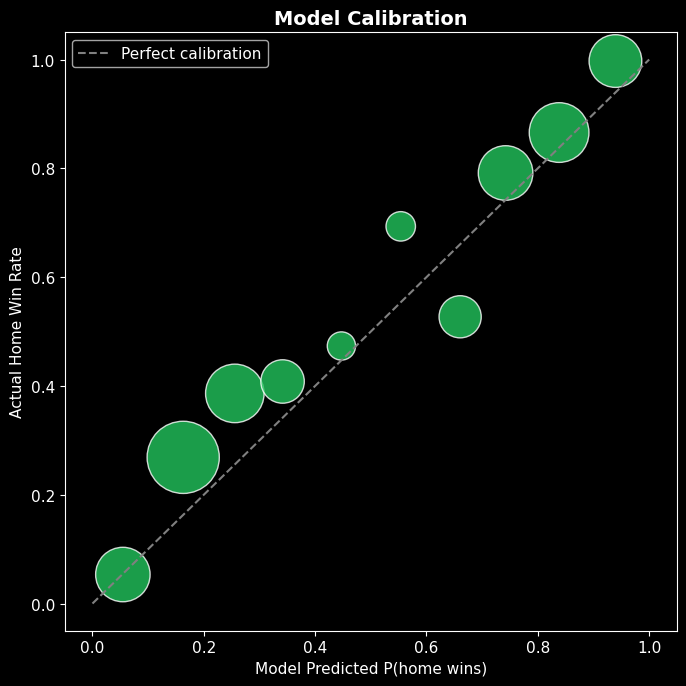

In [27]:
# Calibration plot: for snapshots where we know the outcome
# Group model predictions into bins and check actual win rate

has_outcome = snaps[snaps['home_won'].notna()].copy()

if len(has_outcome) > 0:
    print(f"Snapshots with known outcomes: {len(has_outcome)}")
    has_outcome['model_bin'] = pd.cut(has_outcome['model_win_prob'], bins=10, labels=False)
    cal = has_outcome.groupby('model_bin').agg(
        pred_mean=('model_win_prob', 'mean'),
        actual_mean=('home_won', 'mean'),
        count=('home_won', 'count')
    ).dropna()
    
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
    ax.scatter(cal['pred_mean'], cal['actual_mean'], s=cal['count']*2, c='#22c55e', alpha=0.8, edgecolors='white')
    ax.set_xlabel('Model Predicted P(home wins)')
    ax.set_ylabel('Actual Home Win Rate')
    ax.set_title('Model Calibration', fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No snapshots with known outcomes yet — calibration plot will populate as games finish.")
    print(f"Total snapshots available: {len(snaps)}")
    
    # Show model vs market proxy distribution instead
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(snaps['model_win_prob'].dropna(), bins=40, color='#22c55e', alpha=0.7, label='Model', edgecolor='white', linewidth=0.3)
    axes[0].set_title('Distribution of Model P(home wins)', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('P(home wins)')
    axes[0].legend()
    
    valid = snaps[snaps['polymarket_home_prob'].notna()]
    if len(valid) > 0:
        axes[1].scatter(valid['polymarket_home_prob'], valid['model_win_prob'], alpha=0.15, s=10, c='#a78bfa')
        axes[1].plot([0, 1], [0, 1], '--', color='#facc15', alpha=0.7, label='Agreement line')
        axes[1].set_xlabel('Market P(home wins)')
        axes[1].set_ylabel('Model P(home wins)')
        axes[1].set_title('Model vs Market (all snapshots)', fontsize=13, fontweight='bold')
        axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## 5. Live Game Trajectories — Model vs Market Over Time

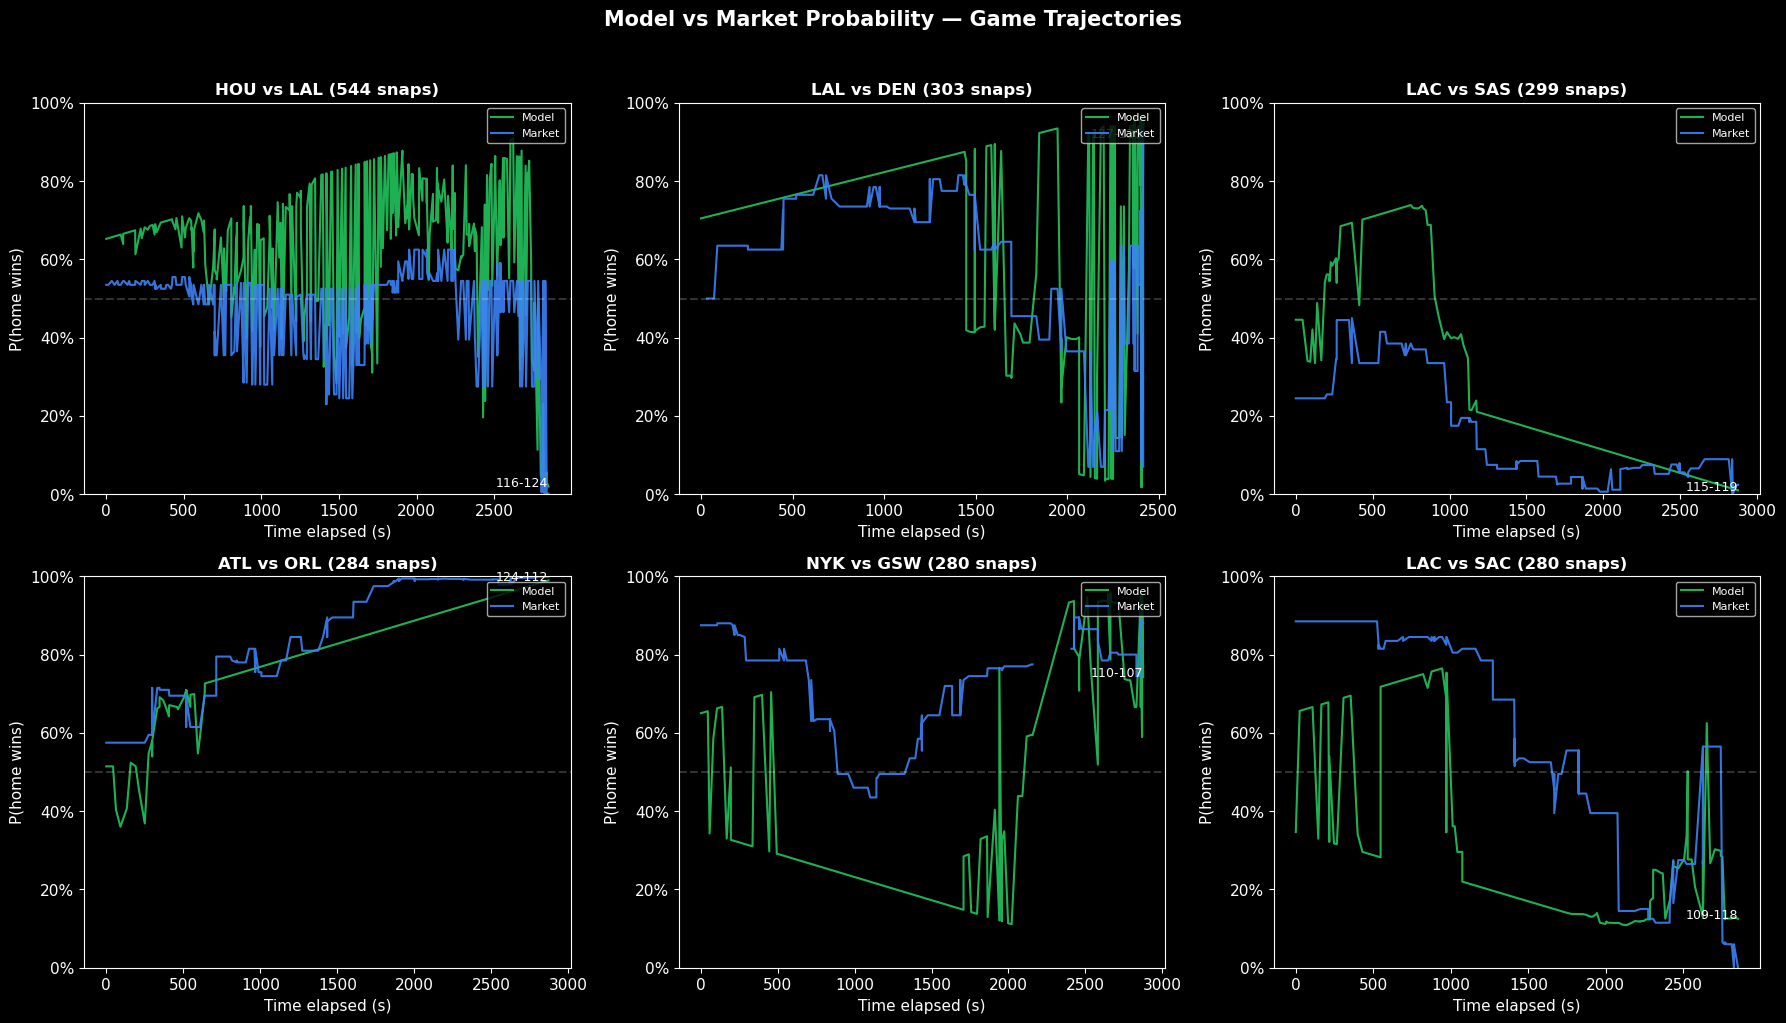

In [28]:
# Plot model vs market probability trajectories for games with most snapshots
games_by_snaps = snaps.groupby(['home_tricode', 'away_tricode']).size().sort_values(ascending=False)
top_games = games_by_snaps.head(6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, ((home, away), count) in enumerate(top_games.items()):
    if idx >= 6:
        break
    ax = axes[idx]
    game = snaps[(snaps['home_tricode'] == home) & (snaps['away_tricode'] == away)].sort_values('game_seconds_left', ascending=False)
    
    time_elapsed = game['game_seconds_left'].max() - game['game_seconds_left']
    
    ax.plot(time_elapsed, game['model_win_prob'], color='#22c55e', linewidth=1.5, label='Model', alpha=0.9)
    
    if game['polymarket_home_prob'].notna().any():
        ax.plot(time_elapsed, game['polymarket_home_prob'], color='#3b82f6', linewidth=1.5, label='Market', alpha=0.9)
    
    ax.axhline(y=0.5, color='white', linestyle='--', alpha=0.2)
    ax.set_ylim(0, 1)
    ax.set_title(f'{home} vs {away} ({count} snaps)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time elapsed (s)')
    ax.set_ylabel('P(home wins)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8, loc='upper right')
    
    # Add score annotation for last snapshot
    last = game.iloc[-1]
    ax.annotate(f'{int(last["home_score"])}-{int(last["away_score"])}', 
                xy=(time_elapsed.iloc[-1], game['model_win_prob'].iloc[-1]),
                fontsize=9, color='white', ha='right')

plt.suptitle('Model vs Market Probability — Game Trajectories', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Model Edge Heatmap — Margin vs Time Remaining

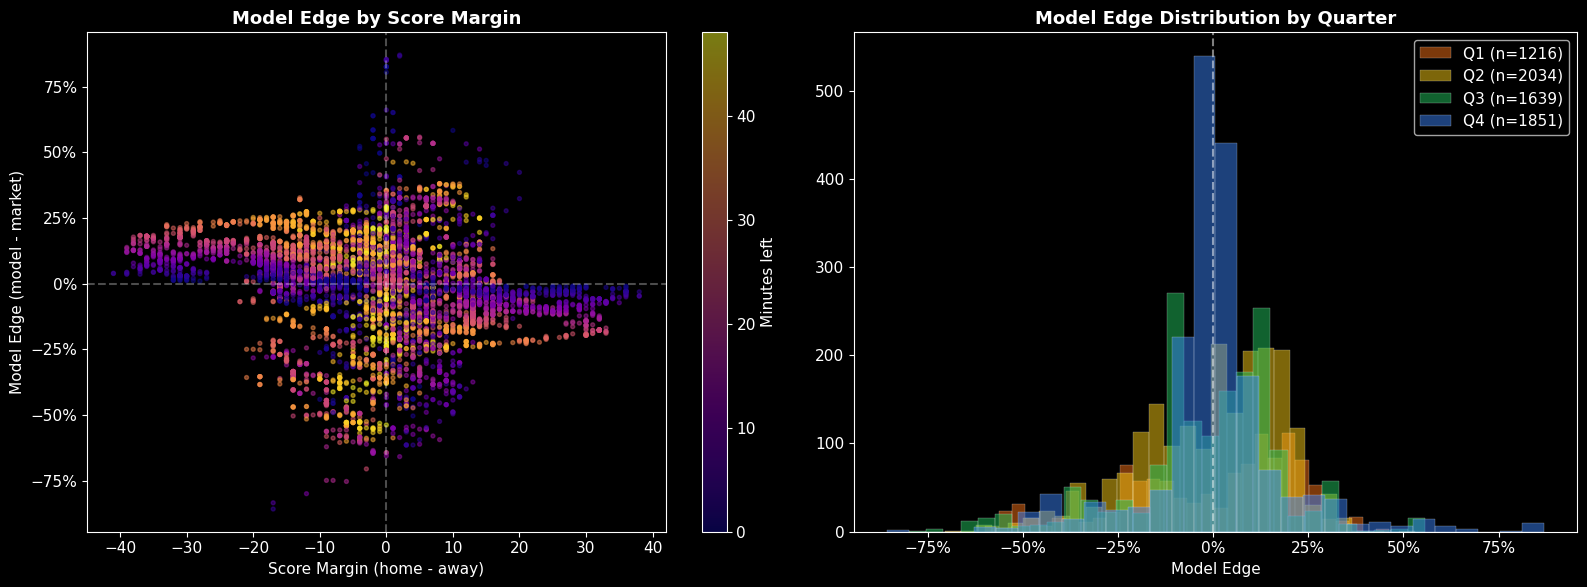


Model Edge Summary by Quarter:
          mean    std    min    max  count
quarter                                   
Q1      -0.017  0.235 -0.600  0.463   1216
Q2      -0.005  0.188 -0.706  0.531   2034
Q3      -0.016  0.202 -0.800  0.558   1639
Q4       0.003  0.180 -0.858  0.870   1851


In [29]:
# How does model edge (model - market) vary by score margin and game time?
valid = snaps[snaps['polymarket_home_prob'].notna()].copy()

if len(valid) > 100:
    valid['margin'] = valid['home_score'] - valid['away_score']
    valid['minutes_left'] = valid['game_seconds_left'] / 60
    valid['model_edge'] = valid['model_win_prob'] - valid['polymarket_home_prob']
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter: margin vs model edge, colored by time
    sc = axes[0].scatter(valid['margin'], valid['model_edge'], 
                         c=valid['minutes_left'], cmap='plasma', s=8, alpha=0.5)
    axes[0].axhline(y=0, color='white', linestyle='--', alpha=0.3)
    axes[0].axvline(x=0, color='white', linestyle='--', alpha=0.3)
    axes[0].set_xlabel('Score Margin (home - away)')
    axes[0].set_ylabel('Model Edge (model - market)')
    axes[0].set_title('Model Edge by Score Margin', fontsize=13, fontweight='bold')
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.colorbar(sc, ax=axes[0], label='Minutes left')
    
    # Model edge distribution by quarter
    valid['quarter'] = valid['period'].clip(upper=4).map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})
    for q, color in [('Q1', '#f97316'), ('Q2', '#facc15'), ('Q3', '#22c55e'), ('Q4', '#3b82f6')]:
        q_data = valid[valid['quarter'] == q]['model_edge']
        if len(q_data) > 0:
            axes[1].hist(q_data, bins=30, alpha=0.5, color=color, label=f'{q} (n={len(q_data)})', edgecolor='white', linewidth=0.3)
    
    axes[1].axvline(x=0, color='white', linestyle='--', alpha=0.5)
    axes[1].set_title('Model Edge Distribution by Quarter', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Model Edge')
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary stats
    print("\nModel Edge Summary by Quarter:")
    print(valid.groupby('quarter')['model_edge'].agg(['mean', 'std', 'min', 'max', 'count']).round(3).to_string())
else:
    print(f"Only {len(valid)} snapshots with market data — need more for meaningful analysis")

## 7. Trade Timing — When Does the Bot Trade?

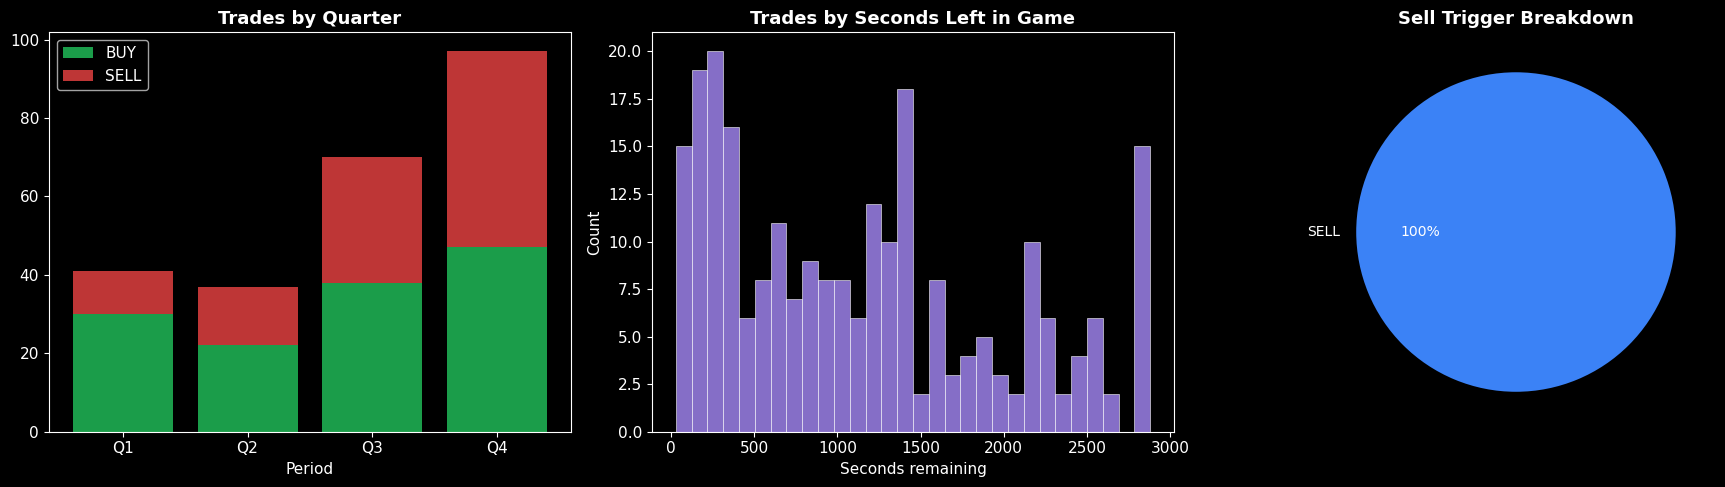

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Trades by quarter
if 'period' in trades.columns:
    q_counts = trades.groupby('period').size()
    buy_q = buys.groupby('period').size()
    sell_q = sells.groupby('period').size()
    
    x = sorted(set(buy_q.index) | set(sell_q.index))
    buy_vals = [buy_q.get(q, 0) for q in x]
    sell_vals = [sell_q.get(q, 0) for q in x]
    
    axes[0].bar(x, buy_vals, color='#22c55e', label='BUY', alpha=0.8)
    axes[0].bar(x, sell_vals, bottom=buy_vals, color='#ef4444', label='SELL', alpha=0.8)
    axes[0].set_title('Trades by Quarter', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Period')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f'Q{int(q)}' if q <= 4 else f'OT{int(q-4)}' for q in x])
    axes[0].legend()

# Trades by game seconds left
if 'secs_left' in trades.columns:
    valid_secs = trades[trades['secs_left'].notna() & (trades['secs_left'] > 0)]
    axes[1].hist(valid_secs['secs_left'], bins=30, color='#a78bfa', edgecolor='white', linewidth=0.5, alpha=0.8)
    axes[1].set_title('Trades by Seconds Left in Game', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Seconds remaining')
    axes[1].set_ylabel('Count')

# Sell reasons breakdown
sell_types = sells['action'].apply(lambda x: x.split('(')[0] if '(' in x else x)
type_counts = sell_types.value_counts()
if len(type_counts) > 0:
    colors = ['#3b82f6', '#f97316', '#22c55e', '#ef4444', '#a78bfa'][:len(type_counts)]
    axes[2].pie(type_counts.values, labels=type_counts.index, colors=colors, 
                autopct='%1.0f%%', textprops={'fontsize': 10})
    axes[2].set_title('Sell Trigger Breakdown', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Per-Game Breakdown

PnL by Game (sorted by total PnL)
Game                                Trades    W/L  Total PnL      Avg      Best     Worst
------------------------------------------------------------------------------------------
Kings                                   16  9W/7L $  +248.75 $ +15.55 $ +221.67 $  -22.06
Suns                                     3  3W/0L $   +91.32 $ +30.44 $  +45.83 $  +10.87
Wizards                                  3  2W/1L $   +88.26 $ +29.42 $ +112.50 $  -33.33
Warriors                                 2  1W/1L $   +55.74 $ +27.87 $  +71.43 $  -15.69
Knicks                                  11  6W/5L $   +14.78 $  +1.34 $  +28.79 $  -27.78
Cavaliers                                1  1W/0L $    +5.26 $  +5.26 $   +5.26 $   +5.26
Timberwolves                            10  7W/3L $    +0.44 $  +0.04 $   +8.46 $  -32.61
Trail Blazers                            1  0W/1L $    -0.70 $  -0.70 $   -0.70 $   -0.70
Lakers                                   1  0W/1L $    -8.33 $  -

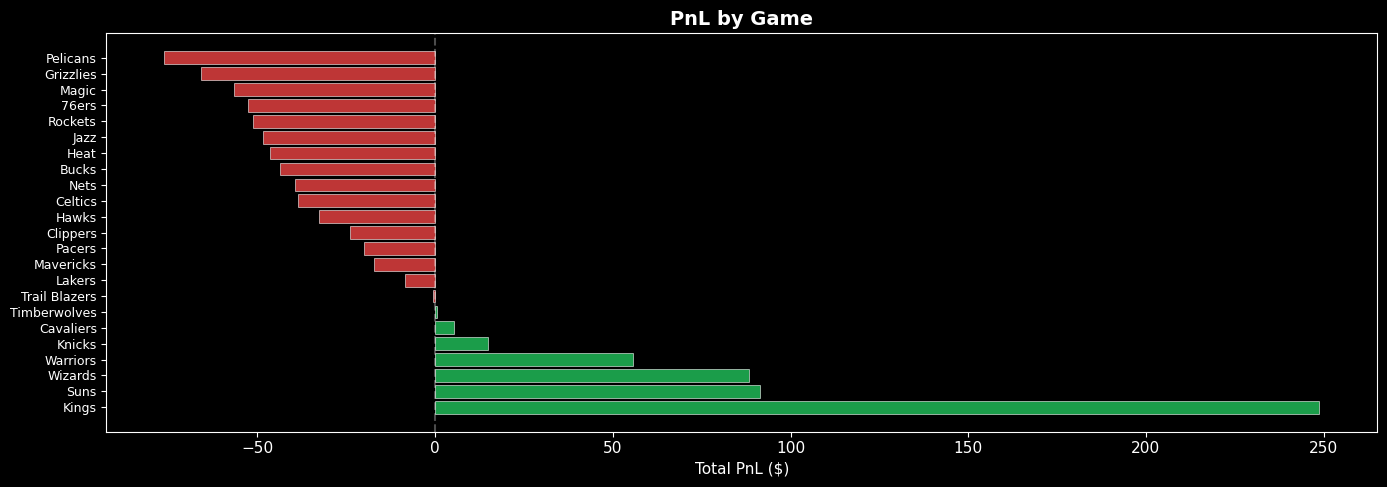

In [31]:
# Group resolved trades by game and show PnL per game
game_pnl = resolved.groupby('target_team').agg(
    trades=('pnl', 'count'),
    total_pnl=('pnl', 'sum'),
    avg_pnl=('pnl', 'mean'),
    wins=('pnl', lambda x: (x > 0).sum()),
    losses=('pnl', lambda x: (x < 0).sum()),
    best=('pnl', 'max'),
    worst=('pnl', 'min')
).sort_values('total_pnl', ascending=False)

print("PnL by Game (sorted by total PnL)")
print("=" * 90)
print(f"{'Game':<35} {'Trades':>6} {'W/L':>6} {'Total PnL':>10} {'Avg':>8} {'Best':>9} {'Worst':>9}")
print("-" * 90)
for game, row in game_pnl.iterrows():
    game_str = str(game)[:34]
    wl = f"{int(row['wins'])}W/{int(row['losses'])}L"
    print(f"{game_str:<35} {int(row['trades']):>6} {wl:>6} ${row['total_pnl']:>+9.2f} ${row['avg_pnl']:>+7.2f} ${row['best']:>+8.2f} ${row['worst']:>+8.2f}")
print("-" * 90)
print(f"{'TOTAL':<35} {len(resolved):>6} {'':<6} ${resolved['pnl'].sum():>+9.2f}")

# Bar chart
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#22c55e' if p > 0 else '#ef4444' for p in game_pnl['total_pnl']]
ax.barh(range(len(game_pnl)), game_pnl['total_pnl'], color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(game_pnl)))
ax.set_yticklabels(game_pnl.index, fontsize=9)
ax.set_xlabel('Total PnL ($)')
ax.set_title('PnL by Game', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='white', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Live Observation Coverage & Model Confidence

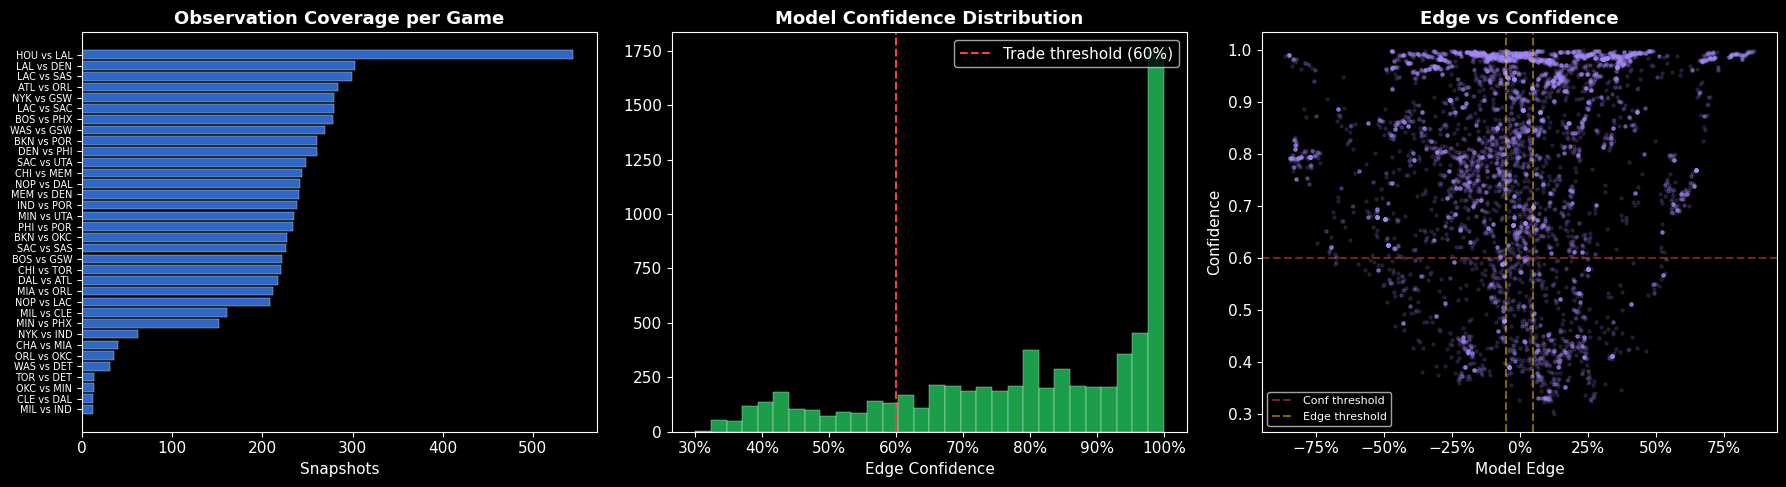


Total live observations: 6,807
Games observed: 34
Avg snapshots per game: 200
With Polymarket odds: 6,740 (99%)
With feature vectors: 6,807 (100%)


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Snapshots per game
game_snaps = snaps.groupby(['home_tricode', 'away_tricode']).size().sort_values(ascending=True)
game_labels = [f'{h} vs {a}' for h, a in game_snaps.index]
axes[0].barh(range(len(game_snaps)), game_snaps.values, color='#3b82f6', alpha=0.8, edgecolor='white', linewidth=0.3)
axes[0].set_yticks(range(len(game_snaps)))
axes[0].set_yticklabels(game_labels, fontsize=7)
axes[0].set_xlabel('Snapshots')
axes[0].set_title('Observation Coverage per Game', fontsize=13, fontweight='bold')

# Model confidence distribution
if 'model_edge_confidence' in snaps.columns:
    conf = snaps['model_edge_confidence'].dropna()
    axes[1].hist(conf, bins=30, color='#22c55e', edgecolor='white', linewidth=0.3, alpha=0.8)
    axes[1].axvline(x=0.6, color='#ef4444', linestyle='--', label='Trade threshold (60%)')
    axes[1].set_title('Model Confidence Distribution', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Edge Confidence')
    axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[1].legend()

# Model edge vs confidence
if 'model_edge' in snaps.columns and 'model_edge_confidence' in snaps.columns:
    valid_edge = snaps[snaps['model_edge'].notna() & snaps['model_edge_confidence'].notna()]
    axes[2].scatter(valid_edge['model_edge'], valid_edge['model_edge_confidence'], 
                    alpha=0.15, s=5, c='#a78bfa')
    axes[2].axhline(y=0.6, color='#ef4444', linestyle='--', alpha=0.5, label='Conf threshold')
    axes[2].axvline(x=0.05, color='#facc15', linestyle='--', alpha=0.5, label='Edge threshold')
    axes[2].axvline(x=-0.05, color='#facc15', linestyle='--', alpha=0.5)
    axes[2].set_xlabel('Model Edge')
    axes[2].set_ylabel('Confidence')
    axes[2].set_title('Edge vs Confidence', fontsize=13, fontweight='bold')
    axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary stats
print(f"\nTotal live observations: {len(snaps):,}")
print(f"Games observed: {snaps.groupby(['home_tricode','away_tricode']).ngroups}")
print(f"Avg snapshots per game: {len(snaps) / snaps.groupby(['home_tricode','away_tricode']).ngroups:.0f}")
print(f"With Polymarket odds: {snaps['polymarket_home_prob'].notna().sum():,} ({snaps['polymarket_home_prob'].notna().mean():.0%})")
print(f"With feature vectors: {snaps['feature_vector'].notna().sum():,} ({snaps['feature_vector'].notna().mean():.0%})")

## 10. Model Volatility — How Stable Are Predictions Within a Game?

Model Prediction Volatility (tick-to-tick swing)
Game            Snaps  Model Avg  Model Max    Mkt Avg    Mkt Max  Vol Ratio
-----------------------------------------------------------------------------------------------
OKC vs MIN         13     0.2018      0.766      0.007      0.090      26.9x
CLE vs DAL         12     0.1717      0.674      0.000      0.000        N/A
TOR vs DET         13     0.1515      0.700      0.000      0.000        N/A
MIL vs IND         12     0.1428      0.456      0.000      0.000        N/A
LAL vs DEN        303     0.0925      0.905      0.045      0.655       2.1x
HOU vs LAL        544     0.0861      0.577      0.056      0.544       1.5x
PHI vs POR        234     0.0619      0.635      0.013      0.290       4.7x
NYK vs GSW        280     0.0384      0.648      0.010      0.140       3.8x
BOS vs PHX        278     0.0371      0.442      0.011      0.435       3.4x
MIL vs CLE        161     0.0323      0.215      0.010      0.160       3.3x
SAC vs U

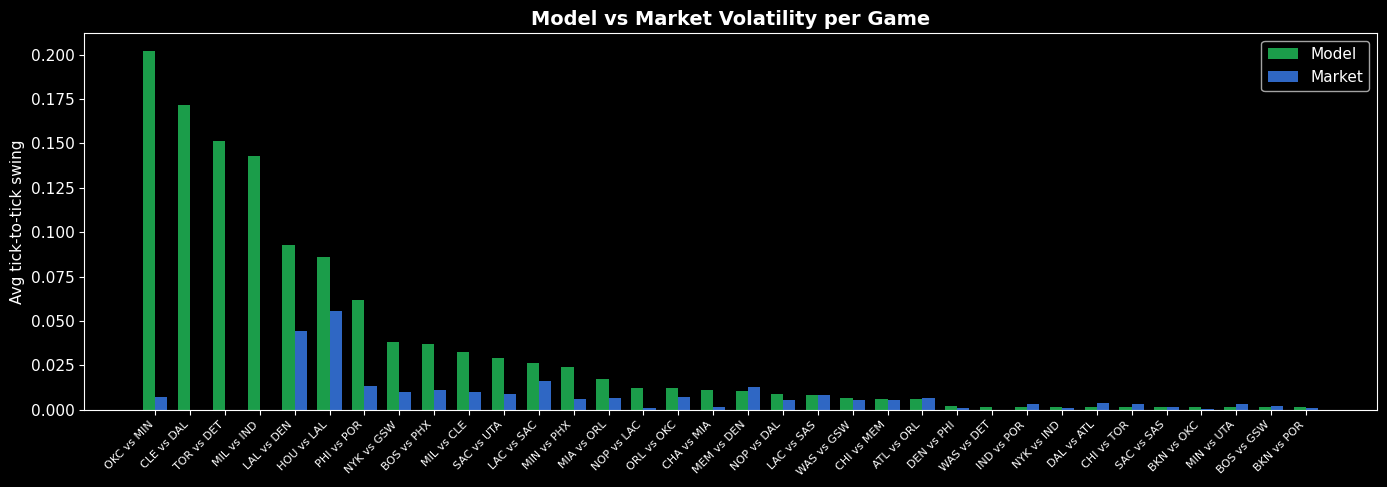


Average volatility ratio (model/market): 3.1x
(Lower is better — 1.0x means model is as stable as the market)


In [33]:
# Measure how much the model swings within each game — compare to market stability
game_groups = snaps.groupby(['home_tricode', 'away_tricode'])

volatility_data = []
for (home, away), group in game_groups:
    if len(group) < 10:
        continue
    g = group.sort_values('game_seconds_left', ascending=False)
    model_diff = g['model_win_prob'].diff().abs()
    model_vol = model_diff.mean()
    model_max_swing = model_diff.max()
    
    market_vol = np.nan
    market_max_swing = np.nan
    if g['polymarket_home_prob'].notna().sum() > 10:
        market_diff = g['polymarket_home_prob'].diff().abs()
        market_vol = market_diff.mean()
        market_max_swing = market_diff.max()
    
    volatility_data.append({
        'game': f'{home} vs {away}',
        'snaps': len(g),
        'model_avg_swing': model_vol,
        'model_max_swing': model_max_swing,
        'market_avg_swing': market_vol,
        'market_max_swing': market_max_swing,
        'volatility_ratio': model_vol / market_vol if not np.isnan(market_vol) and market_vol > 0 else np.nan
    })

vol_df = pd.DataFrame(volatility_data).sort_values('model_avg_swing', ascending=False)

print("Model Prediction Volatility (tick-to-tick swing)")
print("=" * 95)
print(f"{'Game':<15} {'Snaps':>5} {'Model Avg':>10} {'Model Max':>10} {'Mkt Avg':>10} {'Mkt Max':>10} {'Vol Ratio':>10}")
print("-" * 95)
for _, row in vol_df.iterrows():
    mkt_avg = f"{row['market_avg_swing']:.3f}" if not np.isnan(row['market_avg_swing']) else "N/A"
    mkt_max = f"{row['market_max_swing']:.3f}" if not np.isnan(row['market_max_swing']) else "N/A"
    ratio = f"{row['volatility_ratio']:.1f}x" if not np.isnan(row['volatility_ratio']) else "N/A"
    print(f"{row['game']:<15} {row['snaps']:>5} {row['model_avg_swing']:>10.4f} {row['model_max_swing']:>10.3f} {mkt_avg:>10} {mkt_max:>10} {ratio:>10}")

# Bar chart comparison
has_both = vol_df.dropna(subset=['market_avg_swing'])
if len(has_both) > 0:
    fig, ax = plt.subplots(figsize=(14, 5))
    x = range(len(has_both))
    w = 0.35
    ax.bar([i - w/2 for i in x], has_both['model_avg_swing'], w, color='#22c55e', label='Model', alpha=0.8)
    ax.bar([i + w/2 for i in x], has_both['market_avg_swing'], w, color='#3b82f6', label='Market', alpha=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(has_both['game'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Avg tick-to-tick swing')
    ax.set_title('Model vs Market Volatility per Game', fontsize=14, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    avg_ratio = has_both['volatility_ratio'].mean()
    print(f"\nAverage volatility ratio (model/market): {avg_ratio:.1f}x")
    print("(Lower is better — 1.0x means model is as stable as the market)")